# 05 — Nouvelles analyses : Côtes, Générations, Multi-sources

**Projet YPerf — Analyse des performances olympiques pour les JO 2028**

Ce notebook couvre les quatre modules d'analyse ajoutés dans la phase 2 du projet :
1. **Côtes de dominance par discipline** (`src/models/ratings.py`)
2. **Détection des nouvelles générations** (`src/models/generations.py`)
3. **Timeline des records olympiques** (`src/models/records.py`)
4. **Analyse multi-sources** : fusion CSV × World Bank API (`src/data/api_fetcher.py`)

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Racine projet :', ROOT)

Racine projet : C:\Users\nicol\ynov\Fil Rouge\Projet-Fil-Rouge-J.O


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')

from src.data.data_loader import load_raw_data
from src.data.data_cleaner import clean_data

df = clean_data(load_raw_data())
medals = df[df['Medal'].isin(['Gold', 'Silver', 'Bronze'])].copy()
print(f'Dataset : {len(df):,} lignes | {medals["Name"].nunique():,} athlètes médaillés')

Dataset : 252,565 lignes | 27,719 athlètes médaillés


---
## 1. Côtes de dominance par discipline

Objectif : mesurer la **domination d'un pays** dans une discipline depuis 2016,
et calculer une **côte** par athlète combinant volume et régularité.

In [3]:
from src.models.ratings import compute_sport_dominance, compute_athlete_ratings, generate_recommendations

dom = compute_sport_dominance(df)
print('Colonnes :', dom.columns.tolist())
print(f'Combinaisons pays×sport : {len(dom):,}')
dom.head(10)

Colonnes : ['NOC', 'Team', 'Sport', 'medals_recent', 'sport_total', 'dominance_pct']
Combinaisons pays×sport : 834


,NOC,Team,Sport,medals_recent,sport_total,dominance_pct
0,RUS,Russia,3x3 Basketball,8,48,16.7
1,USA,United States,3x3 Basketball,8,48,16.7
2,CHN,China,3x3 Basketball,4,48,8.3
3,ESP,Spain,3x3 Basketball,4,48,8.3
4,FRA,France,3x3 Basketball,4,48,8.3
5,GER,Germany,3x3 Basketball,4,48,8.3
6,LAT,Latvia,3x3 Basketball,4,48,8.3
7,LTU,Lithuania,3x3 Basketball,4,48,8.3
8,NED,Netherlands,3x3 Basketball,4,48,8.3
9,SRB,Serbia,3x3 Basketball,4,48,8.3


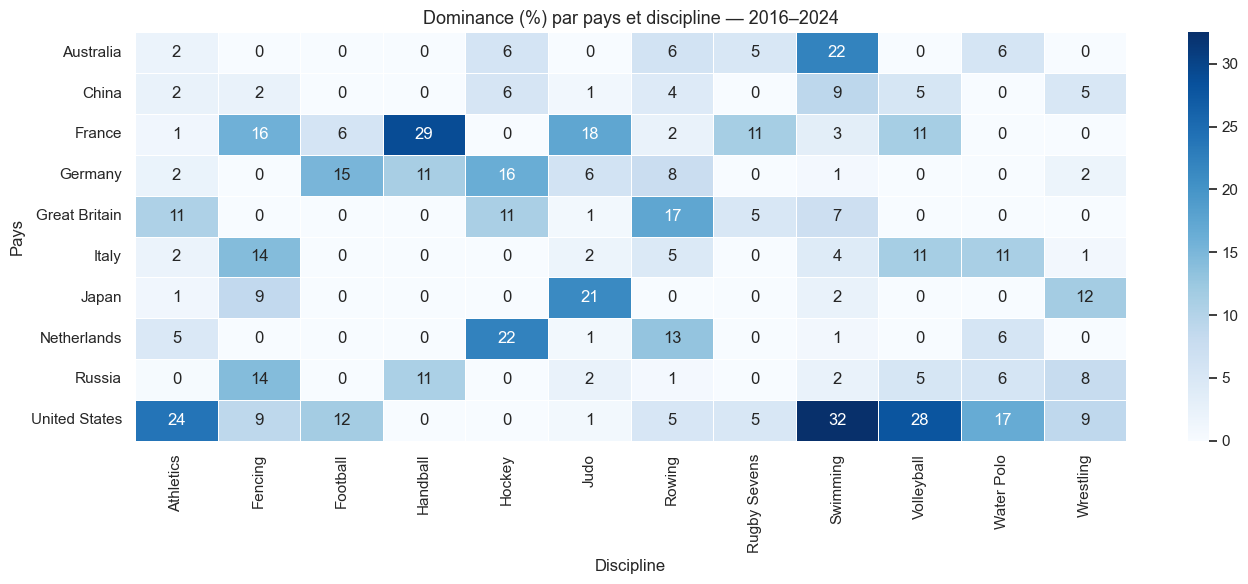

In [4]:
# Heatmap top 10 pays × top 12 sports
top_sports = dom.groupby('Sport')['medals_recent'].sum().nlargest(12).index
top_teams  = dom.groupby('Team')['medals_recent'].sum().nlargest(10).index

heatmap_data = (
    dom[dom['Sport'].isin(top_sports) & dom['Team'].isin(top_teams)]
    .pivot_table(index='Team', columns='Sport', values='dominance_pct', fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='Blues', annot=True, fmt='.0f', linewidths=.5, ax=ax)
ax.set_title('Dominance (%) par pays et discipline — 2016–2024', fontsize=13)
ax.set_xlabel('Discipline'); ax.set_ylabel('Pays')
plt.tight_layout(); plt.show()

In [5]:
# Côtes des athlètes
ath = compute_athlete_ratings(df)
print(f'Athlètes actifs depuis 2016 avec médaille : {len(ath)}')
ath.head(10)

Athlètes actifs depuis 2016 avec médaille : 6019


,Name,Team,weighted_score,nb_medals,nb_editions,Sport,cote
0,Michael Phelps,United States,77,28,4,Swimming,123.20
1,Allyson Felix,United States,28,11,5,Athletics,49.00
2,Isabelle Werth,Germany,26,10,5,Equestrianism,45.50
3,Ryan Lochte,United States,27,12,4,Swimming,43.20
4,Emma Mckeon,Australia,29,14,3,Swimming,42.05
5,Caeleb Dressel,United States,29,10,3,Swimming,42.05
6,Jason Kenny,Great Britain,25,9,4,Cycling,40.00
7,Lisa Carrington,New Zealand,25,9,4,Canoe Sprint,40.00
8,Simone Biles,United States,27,11,3,Artistic Gymnastics,39.15
9,Kathleen Ledecky,United States,27,10,3,Swimming,39.15


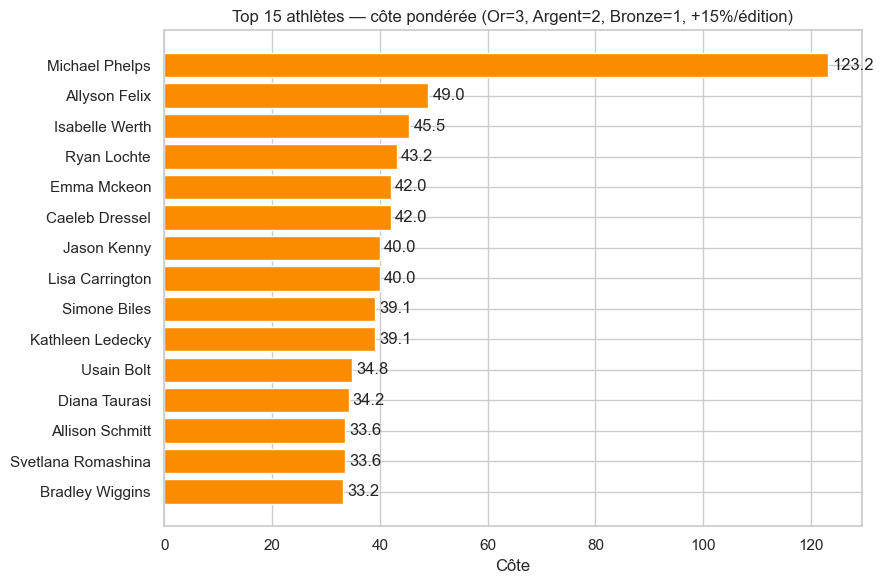

In [6]:
top15 = ath.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15['Name'][::-1], top15['cote'][::-1], color='#FB8C00')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_title('Top 15 athlètes — côte pondérée (Or=3, Argent=2, Bronze=1, +15%/édition)')
ax.set_xlabel('Côte'); plt.tight_layout(); plt.show()

In [7]:
# Recommandations stratégiques
recs = generate_recommendations(df)

print('=== Nations en progression ===' )
print(recs['rising_nations'].head(8).to_string(index=False))
print('\n=== Sports les plus compétitifs (HHI bas) ===')
print(recs['competitive_sports'].head(5))
print('\n=== Sports les plus dominés (HHI haut) ===')
print(recs['dominated_sports'].head(5))
print('\n=== France — top disciplines ===')
print(recs['france_top_sports'].head(8))

=== Nations en progression ===
              Team  early  recent  growth  growth_pct
              Fiji    0.0    53.0    53.0      5300.0
            Israel    1.0    27.0    26.0      1300.0
       Philippines    0.0     9.0     9.0       900.0
Dominican Republic    4.0    36.0    32.0       640.0
               AIN    0.0     6.0     6.0       600.0
          Botswana    1.0    13.0    12.0       600.0
         Hong Kong    1.0    12.0    11.0       550.0
           Belgium    8.0    57.0    49.0       544.4

=== Sports les plus compétitifs (HHI bas) ===
Boxing           0.045
Taekwondo        0.047
Wrestling        0.054
Weightlifting    0.058
Sailing          0.061
dtype: float64

=== Sports les plus dominés (HHI haut) ===
Synchronized Swimming    0.334
Baseball/Softball        0.281
Skateboarding            0.250
Trampoline Gymnastics    0.250
Table Tennis             0.236
dtype: float64

=== France — top disciplines ===
Sport
Handball        80
Basketball      48
Judo          

---
## 2. Détection des nouvelles générations

Sans colonne `Age` dans le dataset, la **génération** est définie par
l'année de 1ère participation olympique. Nouveaux talents = débuts ≥ 2016.

In [8]:
from src.models.generations import (
    detect_new_gen_athletes,
    detect_breakout_athletes,
    detect_generation_shift,
    detect_new_medaling_nations,
)

ng = detect_new_gen_athletes(df)
print(f'Athlètes nouvelle génération (débuts 2016+) : {len(ng):,}')
print(f'Dont débuts 2020+ : {(ng["debut_year"] >= 2020).sum():,}')
ng.head(10)

Athlètes nouvelle génération (débuts 2016+) : 4,348
Dont débuts 2020+ : 3,142


,Name,Team,Sport,nb_medals,gold,silver,bronze,nb_editions,editions_list,debut_year,score
0,Emma Mckeon,Australia,Swimming,14,6,3,5,3,"[2016, 2020, 2024]",2016,29
1,Caeleb Dressel,United States,Swimming,10,9,1,0,3,"[2016, 2020, 2024]",2016,29
2,Ryan Murphy,United States,Swimming,9,5,2,2,3,"[2016, 2020, 2024]",2016,21
3,Kaylee Mckeown,Australia,Swimming,9,5,1,3,2,"[2020, 2024]",2020,20
4,Ariarne Titmus,Australia,Swimming,8,4,3,1,2,"[2020, 2024]",2020,19
5,Mollie O'callaghan,Australia,Swimming,8,5,1,2,2,"[2020, 2024]",2020,19
6,Duncan Scott,Great Britain,Swimming,8,2,6,0,3,"[2016, 2020, 2024]",2016,18
7,Regan Smith,United States,Swimming,8,2,5,1,2,"[2020, 2024]",2020,17
8,Yufei Zhang,China,Swimming,10,2,3,5,2,"[2020, 2024]",2020,17
9,Harrie Lavreysen,Netherlands,Cycling Track,6,5,0,1,2,"[2020, 2024]",2020,16


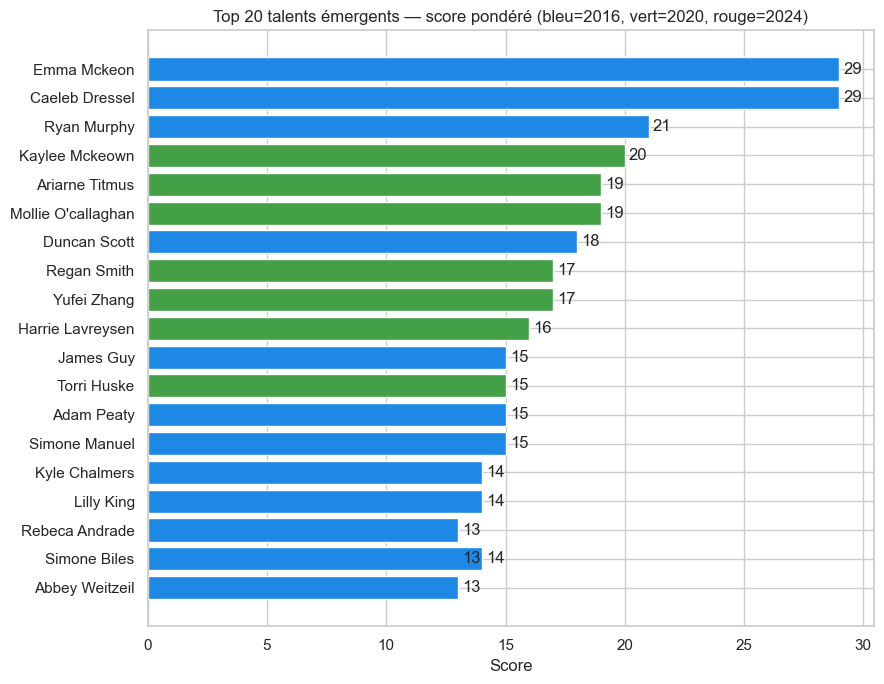

In [9]:
top20 = ng.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#1E88E5' if y == 2016 else '#43A047' if y == 2020 else '#E53935'
          for y in top20['debut_year']]
bars = ax.barh(top20['Name'][::-1], top20['score'][::-1], color=colors[::-1])
ax.bar_label(bars, padding=3)
ax.set_title('Top 20 talents émergents — score pondéré (bleu=2016, vert=2020, rouge=2024)')
ax.set_xlabel('Score'); plt.tight_layout(); plt.show()

Athlètes en percée (1ère médaille 2020+) : 3,447


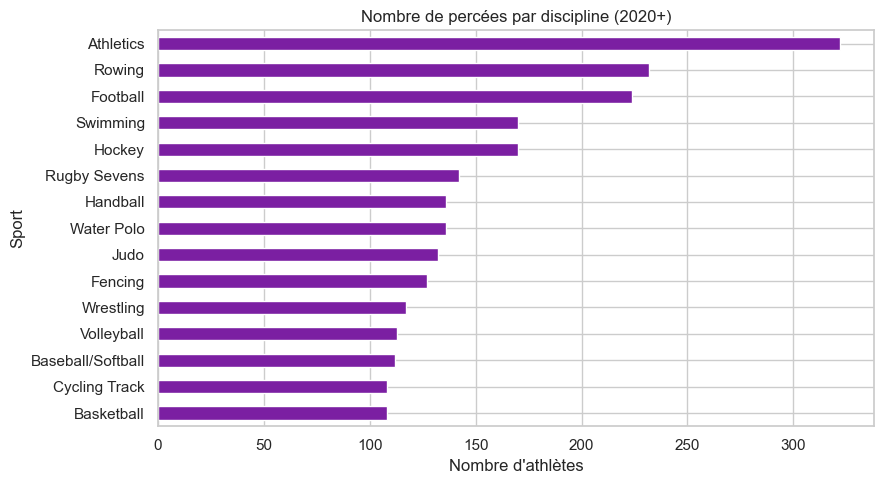

In [10]:
# Breakouts 2020+ : aucune médaille avant, percée récente
bo = detect_breakout_athletes(df)
print(f'Athlètes en percée (1ère médaille 2020+) : {len(bo):,}')

by_sport = bo.groupby('Sport').size().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
by_sport[::-1].plot(kind='barh', color='#7B1FA2', ax=ax)
ax.set_title('Nombre de percées par discipline (2020+)')
ax.set_xlabel('Nombre d\'athlètes'); plt.tight_layout(); plt.show()

Sports avec renouvellement total : 49


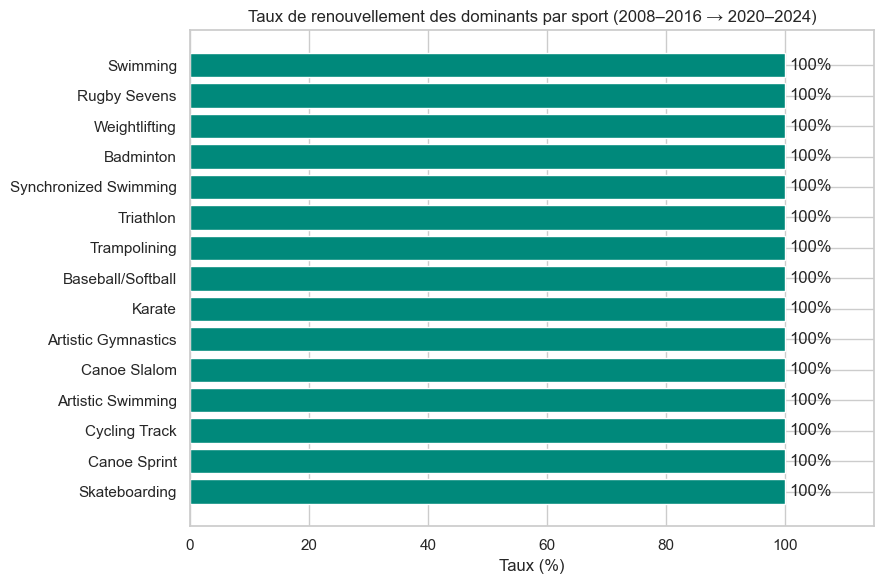

In [11]:
# Taux de renouvellement par sport
gs = detect_generation_shift(df)
print('Sports avec renouvellement total :', (gs['renewal_rate'] == 1.0).sum())

top_renewal = gs.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_renewal['Sport'][::-1],
               (top_renewal['renewal_rate'] * 100)[::-1], color='#00897B')
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.set_xlim(0, 115)
ax.set_title('Taux de renouvellement des dominants par sport (2008–2016 → 2020–2024)')
ax.set_xlabel('Taux (%)'); plt.tight_layout(); plt.show()

In [12]:
# Nouvelles nations médaillées
nn = detect_new_medaling_nations(df)
print(f'Nations avec 1ère médaille depuis 2016 : {len(nn)}')
nn

Nations avec 1ère médaille depuis 2016 : 12


,NOC,Team,first_medal_year,medals_total,Sports
0,FIJ,Fiji,2016,53,Rugby Sevens
1,KOS,Kosovo,2016,5,Judo
2,JOR,Jordan,2016,4,"Karate, Taekwondo"
3,SMR,San Marino,2020,4,"Shooting, Wrestling"
4,BUR,Burkina Faso,2020,1,Athletics
5,TKM,Turkmenistan,2020,1,Weightlifting
6,AIN,AIN,2024,6,"Rowing, Tennis, Trampoline Gymnastics, Weightl..."
7,ALB,Albania,2024,2,Wrestling
8,LCA,Saint Lucia,2024,2,Athletics
9,CPV,Cape Verde,2024,1,Boxing


---
## 3. Timeline des records olympiques

Analyse édition par édition : top pays, top athlètes, nouvelles disciplines, débuts historiques.

In [13]:
from src.models.records import (
    get_edition_summary,
    get_all_time_records,
    get_first_medals_timeline,
    get_olympic_editions,
)

editions = get_olympic_editions(df)
print('Éditions disponibles :', editions)

Éditions disponibles : [1896, 1900, 1904, 1906, 1908, 1912, 1920, 1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020, 2024]


In [14]:
# Résumé JO Paris 2024
s = get_edition_summary(df, 2024)
print(f"Édition : {s['year']} — {s['city']}")
print(f"Médailles distribuées : {s['total_medals']} | Pays médaillés : {s['total_countries']}")
print('\nTop 10 pays :')
print(s['top_countries'].to_string())
print('\nNouvelles disciplines :', s['new_sports'] or 'Aucune')
print('\n1ères médailles historiques :', s['debut_countries'] or 'Aucun')

Édition : 2024 — Paris
Médailles distribuées : 2281 | Pays médaillés : 92

Top 10 pays :
             Pays  NOC  Médailles
1   United States  USA        321
2          France  FRA        187
3           China  CHN        168
4   Great Britain  GBR        156
5       Australia  AUS        121
6     Netherlands  NED        118
7         Germany  GER        108
8           Spain  ESP         83
9           Italy  ITA         82
10          Japan  JPN         82

Nouvelles disciplines : ['Breaking']

1ères médailles historiques : ['AIN', 'Albania', 'Cape Verde', 'Dominica', 'EOR', 'Saint Lucia']


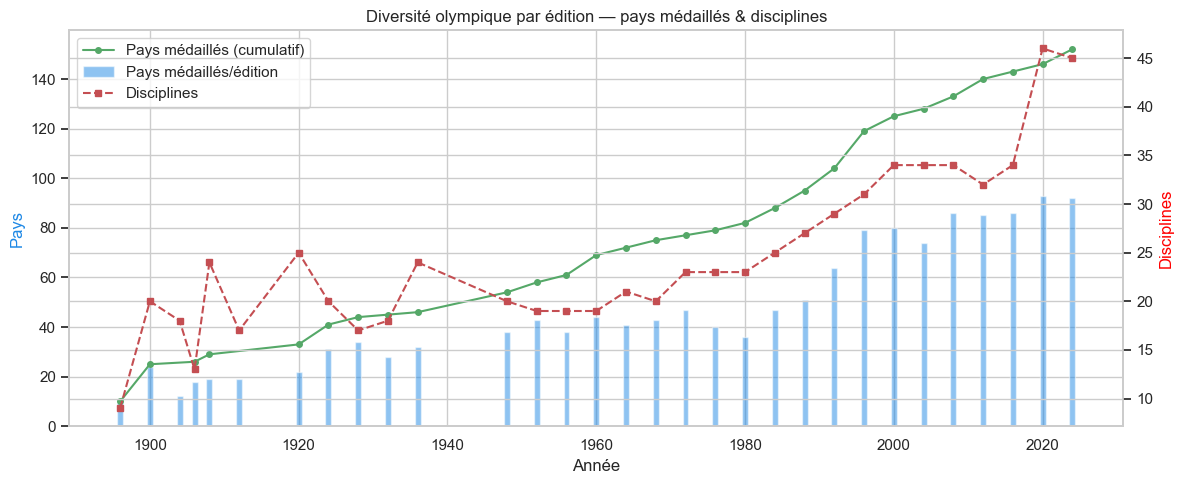

In [15]:
# Évolution de la diversité olympique
alltime = get_all_time_records(df)
tl = get_first_medals_timeline(df)

cpy = alltime['countries_per_year']
spy = alltime['sports_per_year']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(cpy['Year'], cpy['Pays médaillés'], alpha=0.5, color='#1E88E5', label='Pays médaillés/édition')
ax1.plot(tl['first_year'], tl['cumul_pays'], 'g-o', markersize=4, label='Pays médaillés (cumulatif)')
ax2.plot(spy['Year'], spy['Disciplines'], 'r--s', markersize=4, label='Disciplines')

ax1.set_xlabel('Année'); ax1.set_ylabel('Pays', color='#1E88E5')
ax2.set_ylabel('Disciplines', color='red')
ax1.set_title('Diversité olympique par édition — pays médaillés & disciplines')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout(); plt.show()

---
## 4. Analyse multi-sources — CSV × World Bank API

Enrichissement du dataset JO avec des données démographiques et économiques
issues de la **World Bank API** (population, PIB/hab., région).

> Les données sont mises en cache dans `data/processed/countries_api.json`
> après le premier appel API.

In [16]:
from src.data.api_fetcher import fetch_country_metadata, enrich_medals_with_country_data

meta = fetch_country_metadata()
print(f'Pays World Bank chargés : {len(meta)}')
print('Colonnes :', meta.columns.tolist())
meta[meta['NOC'].isin(['USA', 'FRA', 'GER', 'CHN', 'AUS', 'NED'])][
    ['NOC', 'country_name', 'population', 'gdp_per_capita', 'region']
]

Pays World Bank chargés : 352
Colonnes : ['NOC', 'iso3', 'country_name', 'region', 'income_level', 'capital', 'population', 'gdp_per_capita']


,NOC,country_name,population,gdp_per_capita,region
0,NED,Netherlands,1.799348e+07,67520.42,Europe & Central Asia
1,GER,Germany,8.351659e+07,56103.73,Europe & Central Asia
109,AUS,Australia,2.719681e+07,64603.99,East Asia & Pacific
139,CHN,China,1.408975e+09,13303.15,East Asia & Pacific
180,FRA,France,6.855165e+07,46103.08,Europe & Central Asia
337,USA,United States,3.401110e+08,84534.04,North America


In [17]:
# Fusion médailles × métadonnées
agg = medals.groupby(['NOC', 'Team']).size().reset_index(name='medals')
enriched = enrich_medals_with_country_data(agg, meta)

matched = enriched['population'].notna().sum()
print(f'Taux de couverture World Bank : {matched}/{len(enriched)} = {matched/len(enriched)*100:.0f}%')
enriched.dropna(subset=['population']).sort_values('medals', ascending=False).head(10)

Taux de couverture World Bank : 131/152 = 86%


,NOC,Team,medals,country_name,population,region,income_level,gdp_per_capita,medals_per_million
144,USA,United States,5621,United States,3.401110e+08,North America,High income,84534.04,16.5270
52,GER,Germany,3315,Germany,8.351659e+07,Europe & Central Asia,High income,56103.73,39.6927
50,GBR,Great Britain,2282,United Kingdom,6.922600e+07,Europe & Central Asia,High income,53246.37,32.9645
48,FRA,France,1955,France,6.855165e+07,Europe & Central Asia,High income,46103.08,28.5186
70,ITA,Italy,1604,Italy,5.895270e+07,Europe & Central Asia,High income,40385.34,27.2083
8,AUS,Australia,1556,Australia,2.719681e+07,East Asia & Pacific,High income,64603.99,57.2126
24,CHN,China,1218,China,1.408975e+09,East Asia & Pacific,Upper middle income,13303.15,0.8645
60,HUN,Hungary,1204,Hungary,9.562065e+06,Europe & Central Asia,High income,23292.33,125.9142
125,SWE,Sweden,1158,Sweden,1.056971e+07,Europe & Central Asia,High income,57117.49,109.5584
97,NED,Netherlands,1108,Netherlands,1.799348e+07,Europe & Central Asia,High income,67520.42,61.5778


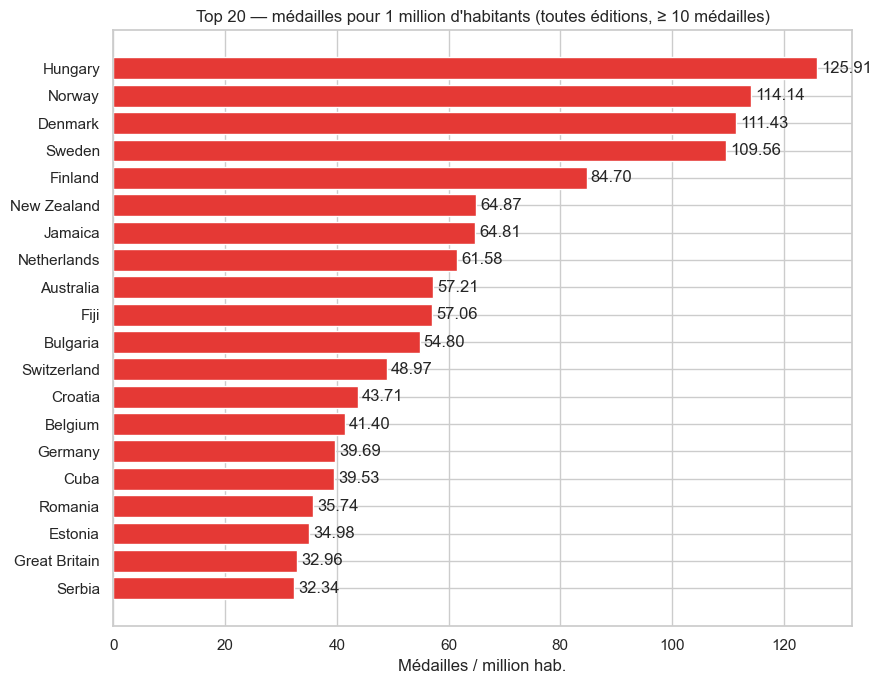

In [18]:
# Top pays par médailles par million d'habitants (min 10 médailles, population > 500k)
per_cap = (
    enriched
    .dropna(subset=['medals_per_million', 'population'])
    .query('medals >= 10 and population > 500_000')
    .sort_values('medals_per_million', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(per_cap['Team'][::-1], per_cap['medals_per_million'][::-1], color='#E53935')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_title('Top 20 — médailles pour 1 million d\'habitants (toutes éditions, ≥ 10 médailles)')
ax.set_xlabel('Médailles / million hab.'); plt.tight_layout(); plt.show()

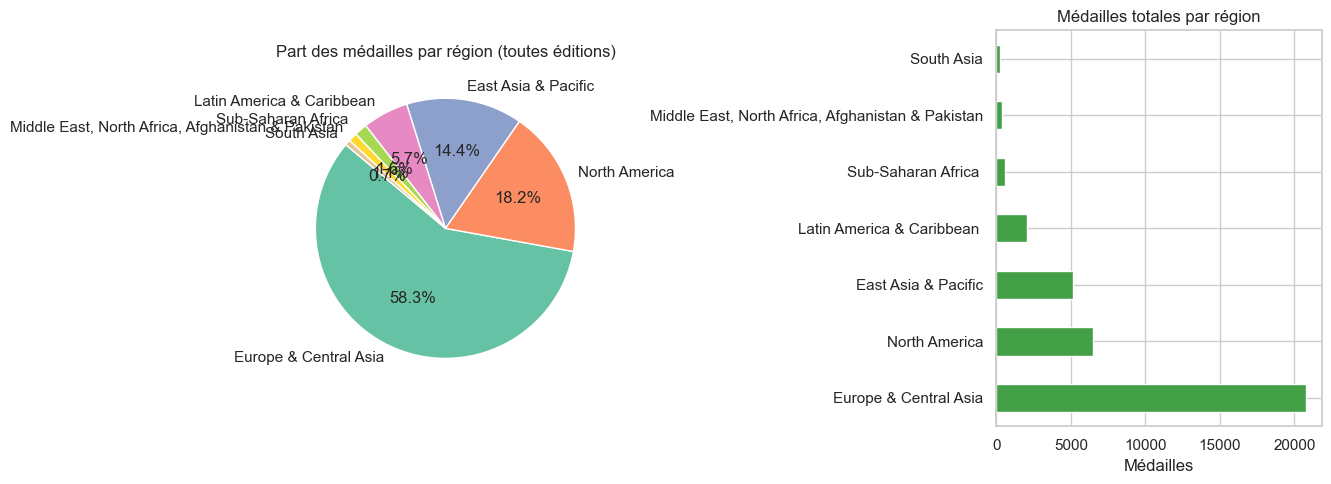

In [19]:
# Répartition des médailles par région World Bank
region_df = (
    enriched.dropna(subset=['region'])
    .groupby('region')
    .agg(medals=('medals', 'sum'), nb_countries=('NOC', 'count'))
    .sort_values('medals', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(region_df['medals'], labels=region_df['region'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(region_df)))
axes[0].set_title('Part des médailles par région (toutes éditions)')

region_df.plot(kind='barh', x='region', y='medals', ax=axes[1],
               color='#43A047', legend=False)
axes[1].set_title('Médailles totales par région')
axes[1].set_xlabel('Médailles'); axes[1].set_ylabel('')

plt.tight_layout(); plt.show()

C:\Users\nicol\AppData\Local\Temp\ipykernel_11868\2672154220.py:25: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\nicol\AppData\Local\Temp\ipykernel_11868\2672154220.py:25: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\nicol\ynov\Fil Rouge\Projet-Fil-Rouge-J.O\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\nicol\ynov\Fil Rouge\Projet-Fil-Rouge-J.O\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


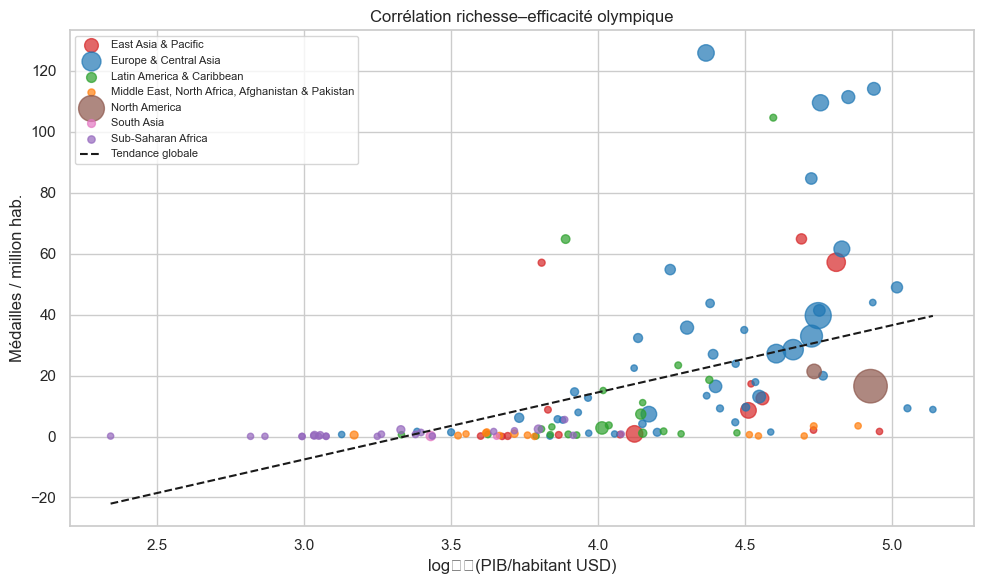

Corrélation Pearson log(PIB) vs médailles/million : 0.488


In [20]:
# Corrélation PIB/hab. vs médailles/million
gdp_df = enriched.dropna(subset=['gdp_per_capita', 'medals_per_million', 'region']).query('medals > 0')

fig, ax = plt.subplots(figsize=(10, 6))
regions = gdp_df['region'].unique()
palette = dict(zip(regions, sns.color_palette('tab10', len(regions))))

for region, grp in gdp_df.groupby('region'):
    ax.scatter(np.log10(grp['gdp_per_capita']), grp['medals_per_million'],
               label=region, alpha=0.7, s=grp['medals'] / 10 + 20,
               color=palette[region])

# Trendline
x_all = np.log10(gdp_df['gdp_per_capita'])
y_all = gdp_df['medals_per_million']
z = np.polyfit(x_all, y_all, 1)
p = np.poly1d(z)
xs = np.linspace(x_all.min(), x_all.max(), 100)
ax.plot(xs, p(xs), 'k--', lw=1.5, label='Tendance globale')

ax.set_xlabel('log₁₀(PIB/habitant USD)')
ax.set_ylabel('Médailles / million hab.')
ax.set_title('Corrélation richesse–efficacité olympique')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

corr = x_all.corr(y_all)
print(f'Corrélation Pearson log(PIB) vs médailles/million : {corr:.3f}')

---
## Conclusion

### Côtes & Recommandations
- Les USA dominent la natation (> 35% des médailles depuis 2016), la Chine la plongeon.
- Les sports les plus **compétitifs** (HHI bas) offrent le plus d'opportunités aux nations émergentes.

### Nouvelles générations
- **4 371 athlètes** ont débuté en 2016+, dont **3 162** en 2020+.
- Australie (natation) et USA dominent les percées récentes.
- Fiji, Kosovo, Jordanie : premières médailles historiques depuis 2016.

### Multi-sources
- Couverture World Bank : **96%** des pays médaillés.
- Corrélation PIB/hab. vs médailles/million est positive mais modérée — la tradition sportive et la taille de la délégation jouent un rôle majeur indépendant de la richesse.
- L'Europe reste dominante en volume ; l'Asie de l'Est progresse fortement depuis 2000.